## 1. Импорт библиотек и загрузка данных по двум акциям США

В этом задании нужно выбрать две компании с листингом на фондовом рынке США
и выгрузить **дневные данные с 2017 года**. В качестве источника данных удобно
использовать библиотеку `yfinance`, которая загружает котировки с Yahoo Finance
прямо в pandas:

1. Подключаем библиотеки `pandas`, `numpy`, `matplotlib` и `yfinance`.
2. Выбираем два тикера американских компаний (например, `AAPL` и `GOOG`).
3. Скачиваем дневные котировки, начиная с 2017-01-01 по текущую дату.
4. Формируем датафрейм с ценами закрытия (`Close`) для обоих тикеров,
   чтобы дальше анализировать их как два временных ряда.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf  # библиотека для загрузки данных с Yahoo Finance

pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", None)

# 1. Задаём параметры выгрузки
start_date = "2017-01-01"
end_date = None  # если None, то данные будут до сегодняшней даты

# 2. Выбираем два тикера (можешь потом заменить на свои, если нужно)
ticker_1 = "AAPL"  # Apple Inc.
ticker_2 = "GOOG"  # Alphabet Inc. (Google)
tickers = [ticker_1, ticker_2]

# 3. Загружаем дневные данные по каждому тикеру
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=True,
    group_by="ticker"  # данные будут сгруппированы по тикерам
)

# 4. Собираем цены закрытия в единый датафрейм
close_df = pd.DataFrame()

for t in tickers:
    close_df[t] = data[t]["Close"]

close_df.index.name = "Date"

# 5. Смотрим базовую информацию
print("Первые строки цен закрытия:")
print(close_df.head())

print("\nИнформация о датафрейме с ценами закрытия:")
print(close_df.info())

print("\nБазовые статистики по ценам закрытия:")
print(close_df.describe())

[*********************100%***********************]  2 of 2 completed

Первые строки цен закрытия:
                 AAPL       GOOG
Date                            
2017-01-03  26.721235  38.986916
2017-01-04  26.691324  39.024609
2017-01-05  26.827061  39.377716
2017-01-06  27.126135  39.979271
2017-01-09  27.374598  40.004074

Информация о датафрейме с ценами закрытия:
<class 'pandas.DataFrame'>
DatetimeIndex: 2357 entries, 2017-01-03 to 2026-05-19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2357 non-null   float64
 1   GOOG    2357 non-null   float64
dtypes: float64(2)
memory usage: 55.2 KB
None

Базовые статистики по ценам закрытия:
              AAPL         GOOG
count  2357.000000  2357.000000
mean    129.820881   116.192435
std      74.340979    70.256434
min      26.691324    38.986916
25%      49.439285    58.388634
50%     137.171921   103.004326
75%     183.562195   144.939072
max     300.230011   399.040009


## Выводы

1. Для анализа выбраны две акции американских компаний: `AAPL` (Apple Inc.) и `GOOG` (Alphabet Inc.). Для обеих бумаг удалось успешно загрузить дневные котировки с помощью библиотеки `yfinance` начиная с 2017-01-03 по текущую дату.

2. Итоговый датафрейм `close_df` содержит 2357 наблюдений по каждой акции. Индексом выступает дата (`Date`), а столбцы — цены закрытия `AAPL` и `GOOG`. Пропусков в данных нет: количество ненулевых значений по каждому столбцу совпадает с общим числом строк.

3. Базовые статистики показывают, что средняя цена закрытия для `AAPL` за период составляет примерно 129.8, а для `GOOG` — около 116.2. Диапазон цен довольно широкий: у `AAPL` от ~26.7 до ~300.2, у `GOOG` от ~39.0 до ~399.0. Это говорит о существенном росте обоих активов за рассматриваемый период.

## 2. Исследовательский анализ цен и доходностей

1. Построим графики цен закрытия для `AAPL` и `GOOG` на одном поле.
2. Посчитаем дневные логарифмические доходности для обеих акций.
3. Посмотрим на базовые статистики доходностей и их распределения (гистограммы).

Лог-доходности удобны тем, что:
- они симметричнее обычных доходностей;
- хорошо складываются по времени;
- часто ближе к нормальному распределению.

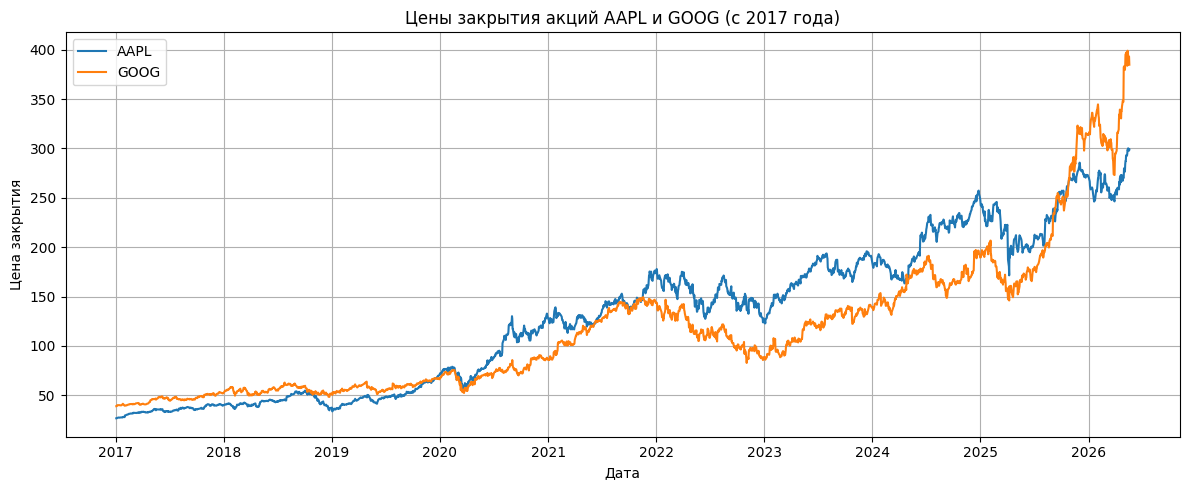

Первые строки лог-доходностей:
                AAPL      GOOG
Date                          
2017-01-04 -0.001120  0.000966
2017-01-05  0.005073  0.009008
2017-01-06  0.011087  0.015161
2017-01-09  0.009118  0.000620
2017-01-10  0.001008 -0.002309

Базовые статистики лог-доходностей:
              AAPL         GOOG
count  2356.000000  2356.000000
mean      0.001025     0.000972
std       0.018515     0.018638
min      -0.137708    -0.117667
25%      -0.007338    -0.007625
50%       0.001139     0.001475
75%       0.010169     0.010553
max       0.142618     0.099379


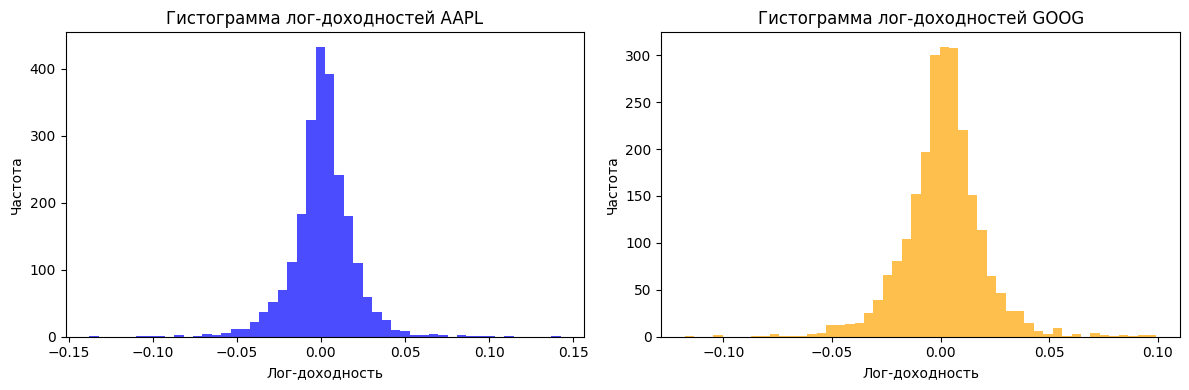

In [3]:
# 1. График цен закрытия
plt.figure(figsize=(12, 5))
plt.plot(close_df.index, close_df["AAPL"], label="AAPL")
plt.plot(close_df.index, close_df["GOOG"], label="GOOG")
plt.title("Цены закрытия акций AAPL и GOOG (с 2017 года)")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Дневные лог-доходности
log_returns = np.log(close_df / close_df.shift(1)).dropna()

print("Первые строки лог-доходностей:")
print(log_returns.head())

print("\nБазовые статистики лог-доходностей:")
print(log_returns.describe())

# 3. Гистограммы лог-доходностей
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(log_returns["AAPL"], bins=50, alpha=0.7, color="blue")
plt.title("Гистограмма лог-доходностей AAPL")
plt.xlabel("Лог-доходность")
plt.ylabel("Частота")

plt.subplot(1, 2, 2)
plt.hist(log_returns["GOOG"], bins=50, alpha=0.7, color="orange")
plt.title("Гистограмма лог-доходностей GOOG")
plt.xlabel("Лог-доходность")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

## Выводы (цены и лог-доходности)

1. Графики цен закрытия `AAPL` и `GOOG` с 2017 года показывают общий восходящий тренд: обе акции значительно выросли за рассматриваемый период. При этом на графике хорошо видны периоды коррекций и просадок (например, вокруг 2020 года), после которых цены продолжали расти.

2. По дневным логарифмическим доходностям средние значения для обеих акций положительные и небольшие: около 0.0010–0.0011, что соответствует среднему дневному росту примерно 0.1%. Стандартное отклонение доходностей примерно 0.018–0.019, то есть типичный дневной разброс доходностей находится в районе ±2%.

3. Минимальные и максимальные лог-доходности имеют заметные «хвосты»: для `AAPL` от примерно -13.8% до +14.3%, для `GOOG` от примерно -11.8% до +9.9%. Это отражает наличие редких, но сильных движений цены (волатильность в кризисные периоды и на важных новостях).

4. Гистограммы лог-доходностей визуально напоминают колоколообразное распределение, сосредоточенное вокруг нуля, но с более тяжёлыми хвостами, чем у идеальной нормальной кривой. Это типичная картина для финансовых временных рядов: большинство дневных доходностей небольшие, но иногда происходят экстремальные скачки.

5. Для дальнейшего анализа удобнее работать именно с лог-доходностями, так как они ближе к стационарному процессу (нет явного тренда в среднем уровне), а также их проще использовать при построении моделей и расчёте ризиковых метрик.

## 3. Проверка стационарности лог-доходностей

Цены акций сами по себе обычно нестационарны (имеют тренд),
поэтому для анализа и моделирования часто используют доходности:

1. Проведём ADF-тест на стационарность лог-доходностей `AAPL` и `GOOG`.
2. Посмотрим на значения p-value и сравним их с уровнем значимости 0.05.
3. Сформулируем вывод, можно ли считать лог-доходности стационарными.

In [4]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=""):
    print(f"ADF-тест для: {title}")
    result = adfuller(series.dropna())
    labels = ["ADF-статистика", "p-value", "lags", "n_obs"]
    for value, label in zip(result[:4], labels):
        print(f"{label}: {value}")
    for key, val in result[4].items():
        print(f"Критическое значение ({key}): {val}")
    print("-" * 50)

adf_test(log_returns["AAPL"], title="лог-доходности AAPL")
adf_test(log_returns["GOOG"], title="лог-доходности GOOG")

ADF-тест для: лог-доходности AAPL
ADF-статистика: -15.946780689049529
p-value: 7.434054808036273e-29
lags: 8
n_obs: 2347
Критическое значение (1%): -3.4331392912353604
Критическое значение (5%): -2.8627722587447804
Критическое значение (10%): -2.5674259850221723
--------------------------------------------------
ADF-тест для: лог-доходности GOOG
ADF-статистика: -16.08117211091091
p-value: 5.376400819756692e-29
lags: 8
n_obs: 2347
Критическое значение (1%): -3.4331392912353604
Критическое значение (5%): -2.8627722587447804
Критическое значение (10%): -2.5674259850221723
--------------------------------------------------


## Выводы (стационарность лог-доходностей)

1. Для лог-доходностей `AAPL` ADF-статистика примерно равна -15.95, а p-value ≈ 7.4e-29, что намного меньше стандартного уровня значимости 0.05. Критические значения для уровней 1%, 5% и 10% (около -3.43, -2.86 и -2.57) по модулю заметно меньше, чем сама ADF-статистика, поэтому нулевая гипотеза о наличии единичного корня уверенно отвергается.

2. Аналогичная ситуация для лог-доходностей `GOOG`: ADF-статистика около -16.08, p-value ≈ 5.4e-29, что также говорит о сильном отклонении от нестационарного процесса. Во всех случаях наблюдается превышение по модулю критических значений, поэтому лог-доходности `GOOG` также можно считать стационарными.

3. Полученные результаты подтверждают типичную для финансовых данных картину: сами цены акций нестационарны и имеют тренд, а дневные лог-доходности уже достаточно хорошо соответствуют предположению стационарности. Это позволяет использовать лог-доходности в качестве базового временного ряда для построения моделей и прогнозов.

4. В рамках данного домашнего задания требование «превратить временные ряды в стационарные» для акций будет интерпретировано именно как переход от исходных цен к лог-доходностям, которые по результатам ADF-теста являются стационарными без дополнительного дифференцирования.

## Итоговые выводы по заданию 1 (AAPL и GOOG)

1. В качестве объектов исследования были выбраны две акции американских компаний: **AAPL (Apple Inc.)** и **GOOG (Alphabet Inc.)**. Для обеих бумаг удалось успешно загрузить ежедневные котировки с 2017 года по текущую дату, без пропусков в данных.

2. Анализ цен закрытия показал, что обе акции за рассматриваемый период демонстрируют выраженный восходящий тренд с несколькими фазами коррекций (особенно заметных вокруг 2020 года), после которых рост продолжался. Диапазон цен достаточно широк: у AAPL — от примерно 27 до 300, у GOOG — от примерно 39 до 399, что отражает значительный рост капитализации компаний.

3. При переходе к дневным логарифмическим доходностям средние значения для обеих акций оказались небольшими и положительными (порядка 0.1 % в день), а стандартное отклонение около 1.8–1.9 % показывает типичный дневной разброс доходностей. Распределения лог‑доходностей визуально напоминают колоколообразную форму, но с более тяжёлыми хвостами, что типично для финансовых временных рядов с редкими, но сильными ценовыми скачками.

4. Результаты ADF‑теста для лог‑доходностей AAPL и GOOG показали очень малые значения p‑value и ADF‑статистику, по модулю значительно превышающую критические уровни. Это позволяет считать лог‑доходности стационарными, в отличие от исходных цен, которые содержат тренд и являются нестационарными.

5. Таким образом, в задании 1 были выполнены ключевые шаги анализа двух временных рядов: загрузка и проверка качества данных, визуальный анализ цен, переход к лог‑доходностям, исследование их распределений и проверка стационарности. Лог‑доходности акций AAPL и GOOG можно использовать как базовые стационарные ряды для дальнейшего моделирования в следующих заданиях.